In [ ]:
#conda install scikit-learn

Retrieving notices: done
Channels:
 - defaults
Platform: osx-arm64
Solving environment: done

## Package Plan ##

  environment location: /opt/anaconda3

  added / updated specs:
    - scikit-learn


The following packages will be downloaded:

    package                    |            build
    ---------------------------|-----------------
    ca-certificates-2025.9.9   |       hca03da5_0         127 KB
    certifi-2025.10.5          |  py312hca03da5_0         157 KB
    libcxx-20.1.8              |       hd7fd590_1         306 KB
    openssl-3.0.18             |       h9b4081a_0         3.1 MB
    scikit-learn-1.7.2         |  py312hc6ded6b_0         8.5 MB
    ------------------------------------------------------------
                                           Total:        12.2 MB

The following packages will be UPDATED:

  ca-certificates                      2025.7.15-hca03da5_0 --> 2025.9.9-hca03da5_0 
  certifi                          2025.8.3-py312hca03da5_0 --> 2025.10.5-

In [1]:
# Setup
import numpy as np
import pandas as pd
from sklearn.model_selection import train_test_split
from sklearn.tree import DecisionTreeClassifier, plot_tree
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import confusion_matrix, accuracy_score, roc_auc_score, roc_curve
import matplotlib.pyplot as plt
import seaborn as sns

np.random.seed(123)

In [7]:
CSV_PATH = "/Users/mosi/Documents/course/1133/wdbc.csv"
df=pd.read_csv(CSV_PATH)

In [9]:
y = df["Diagnosis"].map({"B": 0, "M": 1}).astype(int)
X = df.drop(columns=["ID", "Diagnosis"])
feature_names = X.columns.tolist()

In [ ]:
# 1 80/20 split
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=123, stratify=y
)

In [ ]:
# ===== 2 helper: train & eval one tree =====
def fit_eval_tree(Xtr, ytr, Xte, yte, split="gini", maxdepth=1):
    clf = DecisionTreeClassifier(
        criterion=split, max_depth=maxdepth, min_samples_split=2, random_state=123
    )
    clf.fit(Xtr, ytr)
    #Diagnosis=1
    prob1 = clf.predict_proba(Xte)[:, 1]
    pred  = (prob1 >= 0.5).astype(int)
    cm    = confusion_matrix(yte, pred)
    acc   = accuracy_score(yte, pred)
    auc   = roc_auc_score(yte, prob1)
    fpr, tpr, _ = roc_curve(yte, prob1)
    return dict(model=clf, acc=acc, auc=auc, cm=cm, fpr=fpr, tpr=tpr)

In [ ]:
#3 Grid search: depth 1–6 × {gini, entropy} =====
depths = list(range(1, 7))
splits  = ["gini", "entropy"]

grid_results = {}
rows = []

for sp in splits:
    for d in depths:
        out = fit_eval_tree(X_train, y_train, X_test, y_test, split=sp, maxdepth=d)
        key = f"{sp}_{d}"
        grid_results[key] = out
        rows.append({"split": sp, "depth": d, "Accuracy": out["acc"], "AUC": out["auc"]})

res_tbl = pd.DataFrame(rows).sort_values(by=["split", "depth"]).reset_index(drop=True)
print(res_tbl)

      split  depth  Accuracy       AUC
0   entropy      1  0.894737  0.901786
1   entropy      2  0.868421  0.958168
2   entropy      3  0.921053  0.966435
3   entropy      4  0.938596  0.959821
4   entropy      5  0.921053  0.932540
5   entropy      6  0.921053  0.932540
6      gini      1  0.894737  0.901786
7      gini      2  0.903509  0.918155
8      gini      3  0.903509  0.918320
9      gini      4  0.912281  0.923280
10     gini      5  0.912281  0.897487
11     gini      6  0.912281  0.912698


In [ ]:

#4 Pick best & print
best_idx = res_tbl.sort_values(["Accuracy", "AUC"], ascending=False).index[0]
best_row = res_tbl.loc[best_idx]
best_key = f'{best_row["split"]}_{int(best_row["depth"])}'
best_fit = grid_results[best_key]["model"]
best_acc = grid_results[best_key]["acc"]
best_auc = grid_results[best_key]["auc"]

print("\n-- Best Decision Tree --")
print(best_row.to_string(index=False))
print(f"Best ACC: {best_acc:.3f} | Best AUC: {best_auc:.3f}")


-- Best Decision Tree --
  entropy
        4
 0.938596
 0.959821
Best ACC: 0.939 | Best AUC: 0.960


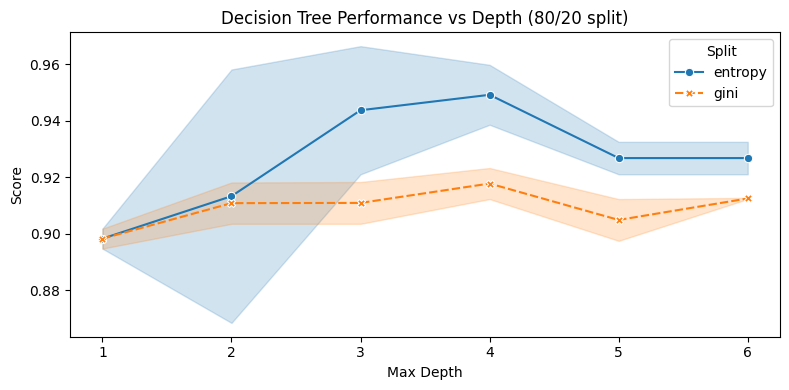

In [ ]:
#5 Visualize performance vs depth
plt.figure(figsize=(8,4))
tmp = res_tbl.melt(id_vars=["split","depth"], value_vars=["Accuracy","AUC"],
                   var_name="Metric", value_name="Value")
sns.lineplot(data=tmp, x="depth", y="Value", hue="split", style="split", markers=True)
plt.xticks(depths)
plt.title("Decision Tree Performance vs Depth (80/20 split)")
plt.xlabel("Max Depth"); plt.ylabel("Score")
plt.legend(title="Split")
plt.tight_layout()
plt.show()

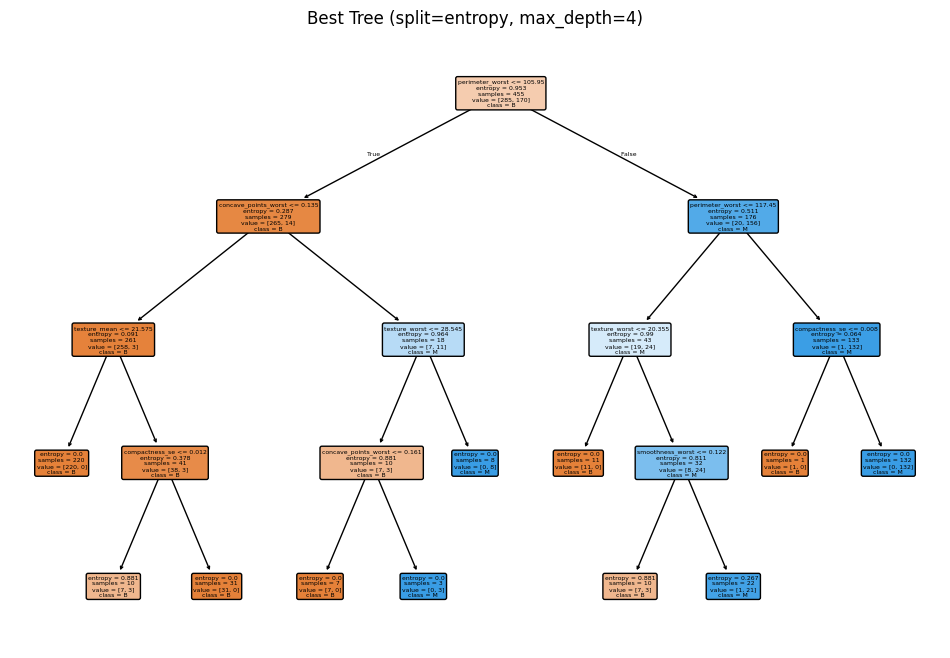

In [ ]:
#6 visualization
plt.figure(figsize=(12,8))
plot_tree(best_fit,
          feature_names=feature_names,
          class_names=["B","M"],  # 0=B, 1=M
          filled=True, rounded=True, impurity=True)
plt.title(f'Best Tree (split={best_row["split"]}, max_depth={int(best_row["depth"])})')
plt.show()

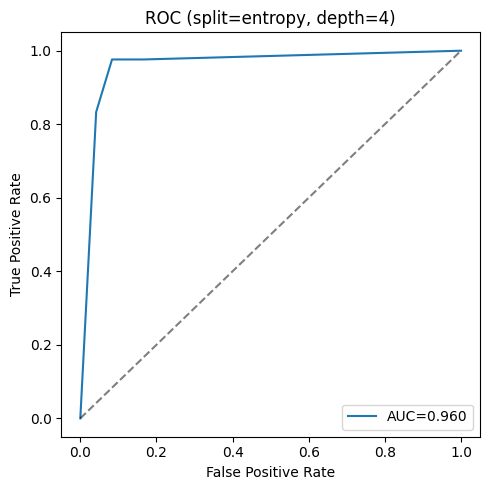


Confusion Matrix (Best):
 [[66  6]
 [ 1 41]]


In [ ]:

#7 ROC & Confusion Matrix for best
out_best = grid_results[best_key]
fpr, tpr = out_best["fpr"], out_best["tpr"]

plt.figure(figsize=(5,5))
plt.plot(fpr, tpr, label=f"AUC={out_best['auc']:.3f}")
plt.plot([0,1],[0,1],"k--", alpha=0.5)
plt.xlabel("False Positive Rate"); plt.ylabel("True Positive Rate")
plt.title(f"ROC (split={best_row['split']}, depth={int(best_row['depth'])})")
plt.legend(loc="lower right")
plt.tight_layout()
plt.show()

print("\nConfusion Matrix (Best):\n", out_best["cm"])

In [17]:
best_by_split = (
    res_tbl.sort_values(["split","Accuracy","AUC"], ascending=[True, False, False])
           .groupby("split", as_index=False).head(1)
           .sort_values("Accuracy", ascending=False)
)
print("\n-- Best by split --")
print(best_by_split.to_string(index=False))


-- Best by split --
  split  depth  Accuracy      AUC
entropy      4  0.938596 0.959821
   gini      4  0.912281 0.923280


In [ ]:
###part3###

In [ ]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from itertools import product
# use sklearn
from sklearn.model_selection import train_test_split, GridSearchCV
from sklearn.tree import DecisionTreeClassifier, plot_tree
from sklearn.ensemble import RandomForestClassifier, AdaBoostClassifier
from sklearn.metrics import (
    accuracy_score, roc_auc_score, confusion_matrix,
    RocCurveDisplay
)

In [ ]:
# Train a RandomForest model (baseline)
rf_base = RandomForestClassifier(
    n_estimators=300, criterion="gini",
    max_depth=None, bootstrap=True, oob_score=True,
    random_state=123, n_jobs=-1
)
rf_base.fit(X_train, y_train)
print("\n[Baseline RF] OOB score:", getattr(rf_base, "oob_score_", None))

y_pred = rf_base.predict(X_test)
y_prob = rf_base.predict_proba(X_test)[:, 1]
print("[Baseline RF] Test ACC: %.3f | AUC: %.3f" %
      (accuracy_score(y_test, y_pred), roc_auc_score(y_test, y_prob)))


[Baseline RF] OOB score: 0.9582417582417583
[Baseline RF] Test ACC: 0.956 | AUC: 0.990


In [ ]:
#Compare RF vs DecisionTree parameters
rf_params = set(RandomForestClassifier().get_params().keys())
dt_params = set(DecisionTreeClassifier().get_params().keys())

same_params = sorted(list(rf_params & dt_params))
only_rf     = sorted(list(rf_params - dt_params))
only_dt     = sorted(list(dt_params - rf_params))

print("\n[Param Comparison]")
print("Same:", len(same_params), same_params)
print("Only in RandomForest:", len(only_rf), only_rf)
print("Only in DecisionTree:", len(only_dt), only_dt)


[Param Comparison]
Same: 12 ['ccp_alpha', 'class_weight', 'criterion', 'max_depth', 'max_features', 'max_leaf_nodes', 'min_impurity_decrease', 'min_samples_leaf', 'min_samples_split', 'min_weight_fraction_leaf', 'monotonic_cst', 'random_state']
Only in RandomForest: 7 ['bootstrap', 'max_samples', 'n_estimators', 'n_jobs', 'oob_score', 'verbose', 'warm_start']
Only in DecisionTree: 1 ['splitter']


In [ ]:
#Manual Grid Search for RF with OOB
# depth = 1..6, criterion in {gini, entropy}, oob_score=True
grid_rows = []
rf_grid_models = {}

for crit, depth in product(["gini", "entropy"], range(1, 7)):
    rf = RandomForestClassifier(
        n_estimators=300,
        criterion=crit,
        max_depth=depth,
        bootstrap=True,
        oob_score=True,     # use oob for eval
        random_state=123,
        n_jobs=-1
    )
    rf.fit(X_train, y_train)

    # OOB
    oob = rf.oob_score_

    # test
    prob = rf.predict_proba(X_test)[:, 1]
    pred = (prob >= 0.5).astype(int)
    acc  = accuracy_score(y_test, pred)
    auc  = roc_auc_score(y_test, prob)

    key = f"{crit}_{depth}"
    rf_grid_models[key] = dict(model=rf, oob=oob, acc=acc, auc=auc)
    grid_rows.append({"criterion": crit, "max_depth": depth,
                      "OOB": oob, "Test_ACC": acc, "Test_AUC": auc})

rf_res = pd.DataFrame(grid_rows).sort_values(
    by=["criterion", "max_depth"]
).reset_index(drop=True)
print("\n[RF Grid (OOB + Test)]")
print(rf_res)

# first by OOB, then by AUC
best_idx = rf_res.sort_values(["OOB", "Test_AUC"], ascending=False).index[0]
rf_best_row = rf_res.loc[best_idx]
rf_best_key = f"{rf_best_row['criterion']}_{int(rf_best_row['max_depth'])}"
rf_best = rf_grid_models[rf_best_key]["model"]

print("\n[Best RF by OOB then AUC]")
print(rf_best_row)


[RF Grid (OOB + Test)]
   criterion  max_depth       OOB  Test_ACC  Test_AUC
0    entropy          1  0.923077  0.929825  0.985780
1    entropy          2  0.942857  0.964912  0.987765
2    entropy          3  0.945055  0.964912  0.988095
3    entropy          4  0.962637  0.956140  0.984458
4    entropy          5  0.964835  0.956140  0.986111
5    entropy          6  0.967033  0.956140  0.986111
6       gini          1  0.920879  0.929825  0.986772
7       gini          2  0.947253  0.964912  0.990410
8       gini          3  0.949451  0.964912  0.991402
9       gini          4  0.949451  0.956140  0.989087
10      gini          5  0.951648  0.947368  0.990079
11      gini          6  0.956044  0.964912  0.990741

[Best RF by OOB then AUC]
criterion     entropy
max_depth           6
OOB          0.967033
Test_ACC      0.95614
Test_AUC     0.986111
Name: 5, dtype: object



[Best RF] Test ACC: 0.956 | AUC: 0.986
[Best RF] Confusion matrix:
 [[68  4]
 [ 1 41]]


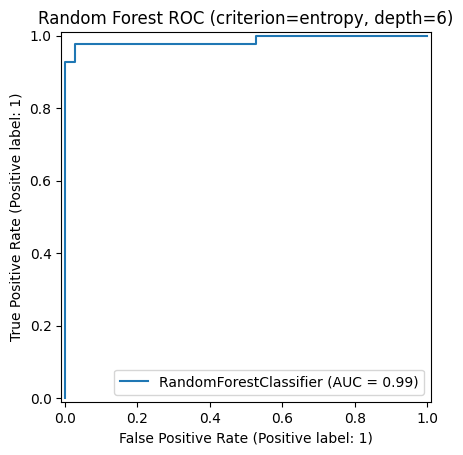

In [ ]:
# Test accuracy of the best RandomForest
rf_prob = rf_best.predict_proba(X_test)[:, 1]
rf_pred = (rf_prob >= 0.5).astype(int)
rf_cm   = confusion_matrix(y_test, rf_pred)
rf_acc  = accuracy_score(y_test, rf_pred)
rf_auc  = roc_auc_score(y_test, rf_prob)
print("\n[Best RF] Test ACC: %.3f | AUC: %.3f" % (rf_acc, rf_auc))
print("[Best RF] Confusion matrix:\n", rf_cm)

# ROC
RocCurveDisplay.from_estimator(rf_best, X_test, y_test)
plt.title(f"Random Forest ROC (criterion={rf_best_row['criterion']}, depth={int(rf_best_row['max_depth'])})")
plt.show()

In [ ]:
# Compare Decision Tree, AdaBoost, Random Forest
dt = DecisionTreeClassifier(random_state=123)
param_grid_dt = {"criterion": ["gini", "entropy"], "max_depth": list(range(1,7))}

grid_dt = GridSearchCV(dt, param_grid_dt, scoring="roc_auc", cv=5, n_jobs=-1)
grid_dt.fit(X_train, y_train)
dt_best = grid_dt.best_estimator_

dt_prob = dt_best.predict_proba(X_test)[:, 1]
dt_pred = (dt_prob >= 0.5).astype(int)
dt_acc  = accuracy_score(y_test, dt_pred)
dt_auc  = roc_auc_score(y_test, dt_prob)

print("\n[Decision Tree] best params:", grid_dt.best_params_)
print("[Decision Tree] Test ACC: %.3f | AUC: %.3f" % (dt_acc, dt_auc))

# -- AdaBoost
ada = AdaBoostClassifier(
    estimator=DecisionTreeClassifier(max_depth=1, random_state=123),
    n_estimators=300,
    learning_rate=0.1,
    random_state=123
)
ada.fit(X_train, y_train)
ada_prob = ada.predict_proba(X_test)[:, 1]
ada_pred = (ada_prob >= 0.5).astype(int)
ada_acc  = accuracy_score(y_test, ada_pred)
ada_auc  = roc_auc_score(y_test, ada_prob)
print("\n[AdaBoost] Test ACC: %.3f | AUC: %.3f" % (ada_acc, ada_auc))


[Decision Tree] best params: {'criterion': 'entropy', 'max_depth': 2}
[Decision Tree] Test ACC: 0.868 | AUC: 0.958

[AdaBoost] Test ACC: 0.974 | AUC: 0.986



[Comparison on Test Set]
                      Model  Accuracy       AUC
0   Decision Tree (CV-best)  0.868421  0.958168
1                  AdaBoost  0.973684  0.986442
2  Random Forest (OOB-best)  0.956140  0.986111


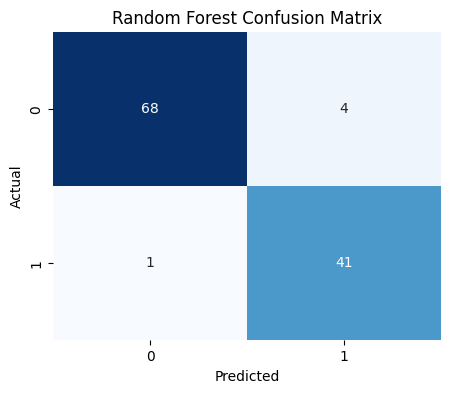

In [ ]:
compare = pd.DataFrame({
    "Model": ["Decision Tree (CV-best)", "AdaBoost", "Random Forest (OOB-best)"],
    "Accuracy": [dt_acc, ada_acc, rf_acc],
    "AUC": [dt_auc, ada_auc, rf_auc]
})
print("\n[Comparison on Test Set]")
print(compare)

# Confusion Matrix for Random Forest
plt.figure(figsize=(5,4))
sns.heatmap(rf_cm, annot=True, fmt="d", cmap="Blues", cbar=False)
plt.xlabel("Predicted"); plt.ylabel("Actual"); plt.title("Random Forest Confusion Matrix")
plt.show()